<a href="https://colab.research.google.com/github/SANGHATI23/sam-brats-robustness-audit/blob/main/03_MedReasoner_Independent_VLM_Replication_Phi35Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1 — Runtime
import sys, platform, torch
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if not torch.cuda.is_available():
    raise RuntimeError("GPU runtime required.")
print("GPU:", torch.cuda.get_device_name(0))
print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")

Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-80GB
GPU memory: 79.3 GB


In [2]:
# CELL 2 — Dependencies
import subprocess, sys
pkgs=[
    "transformers==4.43.4",
    "accelerate>=0.33.0,<1",
    "pillow>=10.3.0",
    "scikit-learn>=1.5",
    "scipy>=1.13",
    "pandas>=2.2",
    "numpy>=1.26",
    "matplotlib>=3.8",
    "tqdm>=4.66"
]
subprocess.run([sys.executable,"-m","pip","install","-q","--upgrade",*pkgs],check=True)
print("Dependencies installed.")

Dependencies installed.


In [3]:
# CELL 3 — Imports/config
import os,re,json,time,random,gc
from pathlib import Path
from datetime import datetime, timezone
import numpy as np, pandas as pd
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, roc_curve
)
from scipy.stats import spearmanr, binomtest
from transformers import AutoModelForCausalLM, AutoProcessor

SEED=2026
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

MODEL_ID="microsoft/Phi-3.5-vision-instruct"
EXPERIMENT_ID="03_independent_vlm_replication_phi35vision"
PROMPT_VERSION="v1.0_matched_to_notebook02"
OVERWRITE_EXISTING=False
MAX_CASES=None
NUM_CROPS=16
MAX_NEW_TOKENS=180

DOMAIN_TARGET={
    "brain_mri":{"domain_text":"brain MRI","target_text":"brain tumor"},
    "kidney_ct":{"domain_text":"kidney CT","target_text":"kidney tumor"},
    "histopathology":{"domain_text":"H&E histopathology","target_text":"cell nuclei"},
}
print(MODEL_ID)

microsoft/Phi-3.5-vision-instruct


In [4]:
# CELL 4 — Drive + assets
from google.colab import drive
DRIVE=Path("/content/drive")
if not (DRIVE/"MyDrive").exists():
    drive.mount(str(DRIVE), force_remount=False)

ROOT=DRIVE/"MyDrive"/"MedReasoner_SAM_2026"
MANIFEST_DIR=ROOT/"01_manifests"
OUTPUT_DIR=ROOT/"03_vlm_outputs"
EVAL_DIR=ROOT/"05_evaluation"
FIG_DIR=ROOT/"06_figures"
LOG_DIR=ROOT/"logs"
for p in [OUTPUT_DIR,EVAL_DIR,FIG_DIR,LOG_DIR]: p.mkdir(parents=True,exist_ok=True)

ASSET_PATH=MANIFEST_DIR/"medreasoner_vlm_asset_manifest.csv"
assets=pd.read_csv(ASSET_PATH)
assert len(assets)==220, f"Expected 220, found {len(assets)}"

missing=[p for p in assets["vlm_input_overlay_path"].astype(str) if not Path(p).exists()]
if missing: raise FileNotFoundError(f"{len(missing)} overlay images missing")

display(assets.groupby("domain").size().reset_index(name="n"))

Mounted at /content/drive


,domain,n
0,brain_mri,94
1,histopathology,36
2,kidney_ct,90


In [5]:
# CELL 5 — Blinded inference manifest
inf=assets[["benchmark_id","domain","vlm_input_overlay_path"]].copy()
inf["domain_text"]=inf["domain"].map(lambda x: DOMAIN_TARGET[x]["domain_text"])
inf["target_text"]=inf["domain"].map(lambda x: DOMAIN_TARGET[x]["target_text"])
inf=inf.sample(frac=1.0,random_state=SEED).reset_index(drop=True)
if MAX_CASES is not None: inf=inf.head(int(MAX_CASES)).copy()

BLIND_PATH=OUTPUT_DIR/f"{EXPERIMENT_ID}_blinded_inference_manifest.csv"
inf.to_csv(BLIND_PATH,index=False)

labels=assets[[
    "benchmark_id","domain","stored_dice","stored_iou",
    "sam_failure_primary","sam_failure_severe","sampling_stratum"
]].copy()

print("Blinded rows:",len(inf))
display(inf.head())

Blinded rows: 220


,benchmark_id,domain,vlm_input_overlay_path,domain_text,target_text
0,MR_0183,kidney_ct,/content/drive/MyDrive/MedReasoner_SAM_2026/02...,kidney CT,kidney tumor
1,MR_0143,kidney_ct,/content/drive/MyDrive/MedReasoner_SAM_2026/02...,kidney CT,kidney tumor
2,MR_0131,kidney_ct,/content/drive/MyDrive/MedReasoner_SAM_2026/02...,kidney CT,kidney tumor
3,MR_0191,kidney_ct,/content/drive/MyDrive/MedReasoner_SAM_2026/02...,kidney CT,kidney tumor
4,MR_0038,brain_mri,/content/drive/MyDrive/MedReasoner_SAM_2026/02...,brain MRI,brain tumor


In [6]:
# CELL 6 — Matched prompt
def build_prompt(domain_text,target_text):
    return f"""
You are performing quality control of an AI-generated medical-image segmentation.

Image domain: {domain_text}
Intended segmentation target: {target_text}

The RED overlay/outline is the candidate segmentation produced by another AI model.
Judge the segmentation only from the visible image-mask relationship.

Choose exactly one decision:
- ACCEPT: the red segmentation appears reasonably aligned with the intended target.
- REVIEW: there is a meaningful visible segmentation problem or substantial uncertainty that warrants human review.
- REJECT: there is an obvious major mismatch, gross mislocalization, or near-complete segmentation failure.

Also estimate the probability that this segmentation is unreliable.

Return ONLY one valid JSON object with exactly these fields:
{{
  "decision": "ACCEPT|REVIEW|REJECT",
  "failure_probability": 0,
  "error_type": "NONE|UNDERSEGMENTATION|OVERSEGMENTATION|MISLOCALIZATION|FRAGMENTATION|BOUNDARY_ERROR|MIXED|UNCERTAIN",
  "grounding": "one concise sentence describing the visible image-mask relationship"
}}

Rules:
- failure_probability must be an integer from 0 to 100.
- Do not give a diagnosis.
- Do not discuss Dice, IoU, ground truth, or unseen information.
- grounding must be no more than 35 words.
- Output JSON only; no markdown.
""".strip()
print(build_prompt("brain MRI","brain tumor"))

You are performing quality control of an AI-generated medical-image segmentation.

Image domain: brain MRI
Intended segmentation target: brain tumor

The RED overlay/outline is the candidate segmentation produced by another AI model.
Judge the segmentation only from the visible image-mask relationship.

Choose exactly one decision:
- ACCEPT: the red segmentation appears reasonably aligned with the intended target.
- REVIEW: there is a meaningful visible segmentation problem or substantial uncertainty that warrants human review.
- REJECT: there is an obvious major mismatch, gross mislocalization, or near-complete segmentation failure.

Also estimate the probability that this segmentation is unreliable.

Return ONLY one valid JSON object with exactly these fields:
{
  "decision": "ACCEPT|REVIEW|REJECT",
  "failure_probability": 0,
  "error_type": "NONE|UNDERSEGMENTATION|OVERSEGMENTATION|MISLOCALIZATION|FRAGMENTATION|BOUNDARY_ERROR|MIXED|UNCERTAIN",
  "grounding": "one concise sentence de

In [7]:
# CELL 7 — Load Phi-3.5-Vision
print("Loading:",MODEL_ID)
t0=time.time()
model=AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="cuda",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    _attn_implementation="eager"
)
processor=AutoProcessor.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    num_crops=NUM_CROPS
)
model.eval()
print(f"Loaded in {(time.time()-t0)/60:.1f} min")
print("Commit:",getattr(model.config,"_commit_hash",None))

Loading: microsoft/Phi-3.5-vision-instruct


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

configuration_phi3_v.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3.5-vision-instruct:
- configuration_phi3_v.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

preprocessor_config.json:   0%|          | 0.00/442 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/670 [00:00<?, ?B/s]

Loaded in 0.5 min
Commit: 12b77fb40b63a2c73c68243d3f767aab688a1b2a


In [8]:
# CELL 8 — Parser
ALLOWED_DECISIONS={"ACCEPT","REVIEW","REJECT"}
ALLOWED_ERRORS={"NONE","UNDERSEGMENTATION","OVERSEGMENTATION","MISLOCALIZATION","FRAGMENTATION","BOUNDARY_ERROR","MIXED","UNCERTAIN"}

def extract_json(text):
    text=str(text).strip()
    text=re.sub(r"^```(?:json)?\s*","",text,flags=re.I)
    text=re.sub(r"\s*```$","",text)
    try:
        obj=json.loads(text)
        if isinstance(obj,dict): return obj
    except: pass
    m=re.search(r"\{.*\}",text,flags=re.S)
    if m:
        try:
            obj=json.loads(m.group(0))
            if isinstance(obj,dict): return obj
        except: pass
    return None

def normalize(raw):
    obj=extract_json(raw)
    out={"parse_ok":False,"decision":None,"failure_probability":np.nan,"error_type":None,"grounding":None}
    if obj is None: return out
    d=str(obj.get("decision","")).strip().upper()
    e=str(obj.get("error_type","")).strip().upper()
    g=str(obj.get("grounding","")).strip()
    try: p=int(round(float(obj.get("failure_probability"))))
    except: p=None
    if d not in ALLOWED_DECISIONS or p is None or not (0<=p<=100) or not g: return out
    if e not in ALLOWED_ERRORS: e="UNCERTAIN"
    out.update({"parse_ok":True,"decision":d,"failure_probability":p,"error_type":e,"grounding":g})
    return out

In [9]:
# CELL 9 — Single-case inference
def run_case(row):
    image=Image.open(str(row["vlm_input_overlay_path"])).convert("RGB")
    prompt_text=build_prompt(str(row["domain_text"]),str(row["target_text"]))
    messages=[{"role":"user","content":"<|image_1|>\n"+prompt_text}]
    prompt=processor.tokenizer.apply_chat_template(messages,tokenize=False,add_generation_prompt=True)
    inputs=processor(prompt,[image],return_tensors="pt").to("cuda:0")
    t0=time.time()
    with torch.inference_mode():
        ids=model.generate(
            **inputs,
            eos_token_id=processor.tokenizer.eos_token_id,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            temperature=0.0,
            use_cache=True
        )
    ids=ids[:,inputs["input_ids"].shape[1]:]
    raw=processor.batch_decode(ids,skip_special_tokens=True,clean_up_tokenization_spaces=False)[0].strip()
    parsed=normalize(raw)
    out={
        "benchmark_id":str(row["benchmark_id"]),
        "domain":str(row["domain"]),
        "model_id":MODEL_ID,
        "prompt_version":PROMPT_VERSION,
        "raw_output":raw,
        "parse_ok":bool(parsed["parse_ok"]),
        "decision":parsed["decision"],
        "failure_probability":None if pd.isna(parsed["failure_probability"]) else int(parsed["failure_probability"]),
        "error_type":parsed["error_type"],
        "grounding":parsed["grounding"],
        "generation_seconds":float(time.time()-t0),
        "timestamp_utc":datetime.now(timezone.utc).isoformat()
    }
    del image,inputs,ids
    return out

In [10]:
# CELL 10 — Smoke test
r=run_case(inf.iloc[0])
print(json.dumps(r,indent=2))
if not r["parse_ok"]: raise RuntimeError("Structured output smoke test failed.")

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
The `seen_tokens` attribute is deprecated and will be removed in v4.41. Use the `cache_position` model input instead.


{
  "benchmark_id": "MR_0183",
  "domain": "kidney_ct",
  "model_id": "microsoft/Phi-3.5-vision-instruct",
  "prompt_version": "v1.0_matched_to_notebook02",
  "raw_output": "{\n  \"decision\": \"ACCEPT\",\n  \"failure_probability\": 10,\n  \"error_type\": \"UNDERSEGMENTATION\",\n  \"grounding\": \"The red outline seems to follow the general shape of the kidney tumor.\"\n}",
  "parse_ok": true,
  "decision": "ACCEPT",
  "failure_probability": 10,
  "error_type": "UNDERSEGMENTATION",
  "grounding": "The red outline seems to follow the general shape of the kidney tumor.",
  "generation_seconds": 5.588671445846558,
  "timestamp_utc": "2026-08-08T02:54:37.874042+00:00"
}


In [11]:
# CELL 11 — Run/resume all cases
PRED_JSONL=OUTPUT_DIR/f"{EXPERIMENT_ID}_predictions.jsonl"

def done_ids(path):
    out=set()
    if not Path(path).exists(): return out
    with open(path,"r",encoding="utf-8") as f:
        for line in f:
            try: out.add(str(json.loads(line)["benchmark_id"]))
            except: pass
    return out

if OVERWRITE_EXISTING and PRED_JSONL.exists(): PRED_JSONL.unlink()
done=done_ids(PRED_JSONL)
errs=[]

for i,(_,row) in enumerate(tqdm(inf.iterrows(),total=len(inf),desc="Phi-3.5-Vision blinded inference"),start=1):
    bid=str(row["benchmark_id"])
    if bid in done: continue
    try:
        result=run_case(row)
        with open(PRED_JSONL,"a",encoding="utf-8") as f:
            f.write(json.dumps(result,ensure_ascii=False)+"\n")
            f.flush()
        done.add(bid)
    except Exception as e:
        errs.append({"benchmark_id":bid,"domain":row["domain"],"error":repr(e)})
    if i%10==0:
        gc.collect(); torch.cuda.empty_cache()

print("Completed:",len(done),"Errors:",len(errs))
if errs:
    edf=pd.DataFrame(errs); display(edf)
    edf.to_csv(LOG_DIR/f"{EXPERIMENT_ID}_runtime_errors.csv",index=False)

Phi-3.5-Vision blinded inference:   0%|          | 0/220 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


Completed: 220 Errors: 0


In [12]:
# CELL 12 — Prediction inventory
rows=[]
with open(PRED_JSONL,"r",encoding="utf-8") as f:
    for line in f:
        if line.strip(): rows.append(json.loads(line))
pred=pd.DataFrame(rows).sort_values("timestamp_utc").drop_duplicates("benchmark_id",keep="last")
pred=pred[pred["benchmark_id"].isin(inf["benchmark_id"])].copy()
PRED_CSV=OUTPUT_DIR/f"{EXPERIMENT_ID}_predictions.csv"
pred.to_csv(PRED_CSV,index=False)

print("Unique:",len(pred),"/",len(inf))
print("Parse success:",f"{pred['parse_ok'].mean()*100:.1f}%")
print("Mean sec/case:",round(pred["generation_seconds"].mean(),2))
display(pred["decision"].value_counts(dropna=False).rename_axis("decision").reset_index(name="n"))
display(pred["error_type"].value_counts(dropna=False).rename_axis("error_type").reset_index(name="n"))

Unique: 220 / 220
Parse success: 100.0%
Mean sec/case: 4.02


,decision,n
0,ACCEPT,92
1,REVIEW,91
2,REJECT,37


,error_type,n
0,UNDERSEGMENTATION,99
1,NONE,84
2,MISLOCALIZATION,37


In [13]:
# CELL 13 — Post-inference labels
ev=pred.merge(labels,on=["benchmark_id","domain"],how="inner",validate="one_to_one")
valid=ev[ev["parse_ok"]==True].copy()

def true_decision(d):
    d=float(d)
    return "REJECT" if d<0.10 else ("REVIEW" if d<0.50 else "ACCEPT")

valid["true_decision"]=valid["stored_dice"].map(true_decision)
valid["true_failure"]=valid["stored_dice"]<0.50
valid["pred_failure"]=valid["decision"].isin(["REVIEW","REJECT"])
valid["failure_score"]=pd.to_numeric(valid["failure_probability"],errors="coerce")/100.0

CASE_PATH=EVAL_DIR/f"{EXPERIMENT_ID}_case_level_evaluation.csv"
valid.to_csv(CASE_PATH,index=False)
print("Evaluable:",len(valid))

Evaluable: 220


In [14]:
# CELL 14 — Metrics
def binary_metrics(df):
    y=df["true_failure"].astype(int).to_numpy()
    p=df["pred_failure"].astype(int).to_numpy()
    s=df["failure_score"].astype(float).to_numpy()
    tn,fp,fn,tp=confusion_matrix(y,p,labels=[0,1]).ravel()
    out={
        "n":len(df),
        "balanced_accuracy":balanced_accuracy_score(y,p),
        "sensitivity_recall":recall_score(y,p,zero_division=0),
        "specificity":tn/(tn+fp) if tn+fp else np.nan,
        "precision":precision_score(y,p,zero_division=0),
        "f1":f1_score(y,p,zero_division=0),
        "false_reassurance_rate":fn/(fn+tp) if fn+tp else np.nan,
        "false_alarm_rate":fp/(fp+tn) if fp+tn else np.nan,
        "tp":int(tp),"tn":int(tn),"fp":int(fp),"fn":int(fn)
    }
    if len(np.unique(y))==2 and np.isfinite(s).all():
        out.update({
            "auroc":roc_auc_score(y,s),
            "auprc":average_precision_score(y,s),
            "brier":brier_score_loss(y,s)
        })
    else:
        out.update({"auroc":np.nan,"auprc":np.nan,"brier":np.nan})
    return out

def multi_metrics(df):
    labels3=["ACCEPT","REVIEW","REJECT"]
    return {
        "accuracy":accuracy_score(df["true_decision"],df["decision"]),
        "macro_f1":f1_score(df["true_decision"],df["decision"],labels=labels3,average="macro",zero_division=0),
        "weighted_f1":f1_score(df["true_decision"],df["decision"],labels=labels3,average="weighted",zero_division=0)
    }

phi_bin=binary_metrics(valid)
phi_multi=multi_metrics(valid)
display(pd.DataFrame([phi_bin]))
display(pd.DataFrame([phi_multi]))

,n,balanced_accuracy,sensitivity_recall,specificity,precision,f1,false_reassurance_rate,false_alarm_rate,tp,tn,fp,fn,auroc,auprc,brier
0,220,0.478015,0.559633,0.396396,0.476562,0.514768,0.440367,0.603604,61,44,67,48,0.480784,0.490639,0.427091


,accuracy,macro_f1,weighted_f1
0,0.372727,0.361593,0.377751


In [15]:
# CELL 15 — Domain metrics
drows=[]
for d,ddf in valid.groupby("domain"):
    m=binary_metrics(ddf); mm=multi_metrics(ddf)
    m["domain"]=d; m["three_class_accuracy"]=mm["accuracy"]; m["three_class_macro_f1"]=mm["macro_f1"]
    drows.append(m)
domain_metrics=pd.DataFrame(drows)
DOMAIN_PATH=EVAL_DIR/f"{EXPERIMENT_ID}_domain_metrics.csv"
domain_metrics.to_csv(DOMAIN_PATH,index=False)
display(domain_metrics)

,n,balanced_accuracy,sensitivity_recall,specificity,precision,f1,false_reassurance_rate,false_alarm_rate,tp,tn,fp,fn,auroc,auprc,brier,domain,three_class_accuracy,three_class_macro_f1
0,94,0.518636,0.977273,0.06,0.477778,0.641791,0.022727,0.94,43,3,47,1,0.596818,0.541446,0.328032,brain_mri,0.340426,0.333900
1,36,0.500000,0.000000,1.00,0.000000,0.000000,1.000000,0.00,0,11,0,25,0.500000,0.694444,0.694444,histopathology,0.305556,0.156028
2,90,0.525000,0.450000,0.60,0.473684,0.461538,0.550000,0.40,18,30,20,22,0.502500,0.437259,0.423611,kidney_ct,0.433333,0.349451


In [16]:
# CELL 16 — Bootstrap 95% CI
def boot_ci(df,metric,n_boot=2000):
    rng=np.random.default_rng(SEED); vals=[]; n=len(df)
    for _ in range(n_boot):
        b=df.iloc[rng.integers(0,n,size=n)]
        try:
            v=binary_metrics(b)[metric]
            if np.isfinite(v): vals.append(v)
        except: pass
    return (np.percentile(vals,2.5),np.percentile(vals,97.5)) if vals else (np.nan,np.nan)

rows=[]
for m in ["balanced_accuracy","sensitivity_recall","specificity","f1","false_reassurance_rate","auroc","auprc","brier"]:
    lo,hi=boot_ci(valid,m)
    rows.append({"metric":m,"estimate":phi_bin[m],"ci95_low":lo,"ci95_high":hi})
ci=pd.DataFrame(rows)
CI_PATH=EVAL_DIR/f"{EXPERIMENT_ID}_bootstrap_95ci.csv"
ci.to_csv(CI_PATH,index=False)
display(ci)

,metric,estimate,ci95_low,ci95_high
0,balanced_accuracy,0.478015,0.412965,0.545346
1,sensitivity_recall,0.559633,0.466102,0.651805
2,specificity,0.396396,0.301724,0.492003
3,f1,0.514768,0.435175,0.589554
4,false_reassurance_rate,0.440367,0.348195,0.533898
5,auroc,0.480784,0.409275,0.555999
6,auprc,0.490639,0.417842,0.570491
7,brier,0.427091,0.372738,0.481345


In [17]:
# CELL 17 — Load Notebook-02 Qwen results
QWEN_PATH=EVAL_DIR/"02_blinded_failure_recognition_qwen25vl7b_case_level_evaluation.csv"
qwen=pd.read_csv(QWEN_PATH)

for c in ["true_failure","pred_failure"]:
    if c in qwen.columns and qwen[c].dtype==object:
        qwen[c]=qwen[c].astype(str).str.lower().map({"true":True,"false":False})
if "failure_score" not in qwen.columns:
    qwen["failure_score"]=pd.to_numeric(qwen["failure_probability"],errors="coerce")/100.0

q_bin=binary_metrics(qwen)
q_multi=multi_metrics(qwen)

comparison=pd.DataFrame([
    {"model":"Qwen2.5-VL-7B-Instruct",**{k:q_bin[k] for k in ["balanced_accuracy","sensitivity_recall","specificity","f1","false_reassurance_rate","auroc","auprc","brier"]},
     "three_class_accuracy":q_multi["accuracy"],"three_class_macro_f1":q_multi["macro_f1"]},
    {"model":"Phi-3.5-Vision-Instruct",**{k:phi_bin[k] for k in ["balanced_accuracy","sensitivity_recall","specificity","f1","false_reassurance_rate","auroc","auprc","brier"]},
     "three_class_accuracy":phi_multi["accuracy"],"three_class_macro_f1":phi_multi["macro_f1"]}
])
COMP_PATH=EVAL_DIR/"03_qwen_vs_phi_matched_model_comparison.csv"
comparison.to_csv(COMP_PATH,index=False)
display(comparison)

,model,balanced_accuracy,sensitivity_recall,specificity,f1,false_reassurance_rate,auroc,auprc,brier,three_class_accuracy,three_class_macro_f1
0,Qwen2.5-VL-7B-Instruct,0.490330,0.926606,0.054054,0.641270,0.073394,0.475122,0.483966,0.344909,0.331818,0.190956
1,Phi-3.5-Vision-Instruct,0.478015,0.559633,0.396396,0.514768,0.440367,0.480784,0.490639,0.427091,0.372727,0.361593


In [18]:
# CELL 18 — Paired model comparison
qsmall=qwen[["benchmark_id","domain","decision","failure_probability","true_failure","true_decision","stored_dice"]].rename(
    columns={"decision":"qwen_decision","failure_probability":"qwen_failure_probability"}
)
psmall=valid[["benchmark_id","domain","decision","failure_probability","true_failure","true_decision","stored_dice"]].rename(
    columns={"decision":"phi_decision","failure_probability":"phi_failure_probability"}
)
paired=psmall.merge(qsmall,on=["benchmark_id","domain","true_failure","true_decision","stored_dice"],validate="one_to_one")
paired["qwen_pred_failure"]=paired["qwen_decision"].isin(["REVIEW","REJECT"])
paired["phi_pred_failure"]=paired["phi_decision"].isin(["REVIEW","REJECT"])
paired["qwen_correct"]=paired["qwen_pred_failure"]==paired["true_failure"]
paired["phi_correct"]=paired["phi_pred_failure"]==paired["true_failure"]
paired["qwen_score"]=pd.to_numeric(paired["qwen_failure_probability"])/100.0
paired["phi_score"]=pd.to_numeric(paired["phi_failure_probability"])/100.0

b=int((paired["qwen_correct"] & ~paired["phi_correct"]).sum())
c=int((~paired["qwen_correct"] & paired["phi_correct"]).sum())
mcnemar_p=float(binomtest(min(b,c),n=b+c,p=0.5).pvalue) if b+c else 1.0
mcnemar=pd.DataFrame([{"paired_n":len(paired),"qwen_correct_phi_wrong":b,"qwen_wrong_phi_correct":c,"exact_mcnemar_p":mcnemar_p}])
MC_PATH=EVAL_DIR/"03_qwen_vs_phi_exact_mcnemar.csv"
mcnemar.to_csv(MC_PATH,index=False)
display(mcnemar)

,paired_n,qwen_correct_phi_wrong,qwen_wrong_phi_correct,exact_mcnemar_p
0,220,40,38,0.909946


In [19]:
# CELL 19 — Paired bootstrap differences
def paired_boot(metric,n_boot=5000):
    rng=np.random.default_rng(SEED); diffs=[]; n=len(paired)
    for _ in range(n_boot):
        d=paired.iloc[rng.integers(0,n,size=n)]
        y=d["true_failure"].astype(int)
        if metric=="balanced_accuracy":
            q=balanced_accuracy_score(y,d["qwen_pred_failure"].astype(int))
            p=balanced_accuracy_score(y,d["phi_pred_failure"].astype(int))
        else:
            if len(np.unique(y))<2: continue
            q=roc_auc_score(y,d["qwen_score"]); p=roc_auc_score(y,d["phi_score"])
        diffs.append(p-q)
    a=np.array(diffs)
    return {
        "metric":metric,
        "difference_phi_minus_qwen":float(a.mean()),
        "ci95_low":float(np.percentile(a,2.5)),
        "ci95_high":float(np.percentile(a,97.5)),
        "bootstrap_probability_phi_gt_qwen":float((a>0).mean())
    }

paired_diff=pd.DataFrame([paired_boot("balanced_accuracy"),paired_boot("auroc")])
DIFF_PATH=EVAL_DIR/"03_qwen_vs_phi_paired_bootstrap_differences.csv"
paired_diff.to_csv(DIFF_PATH,index=False)
display(paired_diff)

,metric,difference_phi_minus_qwen,ci95_low,ci95_high,bootstrap_probability_phi_gt_qwen
0,balanced_accuracy,-0.011954,-0.074466,0.051985,0.3478
1,auroc,0.006578,-0.066497,0.081268,0.5708


In [20]:
# CELL 20 — Agreement + disagreement cases
agree3=float((paired["qwen_decision"]==paired["phi_decision"]).mean())
agree2=float((paired["qwen_pred_failure"]==paired["phi_pred_failure"]).mean())
print("Exact 3-class agreement:",round(agree3,3))
print("Binary agreement:",round(agree2,3))

paired["decision_disagree"]=paired["qwen_decision"]!=paired["phi_decision"]
paired["risk_abs_diff"]=(paired["qwen_score"]-paired["phi_score"]).abs()
dis=paired[paired["decision_disagree"]].sort_values("risk_abs_diff",ascending=False)
DIS_PATH=EVAL_DIR/"03_qwen_vs_phi_model_disagreements.csv"
dis.to_csv(DIS_PATH,index=False)
print("Disagreements:",len(dis))
display(dis.head(30))

Exact 3-class agreement: 0.477
Binary agreement: 0.645
Disagreements: 115


,benchmark_id,domain,phi_decision,phi_failure_probability,true_failure,true_decision,stored_dice,qwen_decision,qwen_failure_probability,qwen_pred_failure,phi_pred_failure,qwen_correct,phi_correct,qwen_score,phi_score,decision_disagree,risk_abs_diff
28,MR_0151,kidney_ct,REJECT,95,False,ACCEPT,0.725275,REVIEW,20,True,True,False,False,0.2,0.95,True,0.75
10,MR_0006,brain_mri,REJECT,95,False,ACCEPT,0.532548,REVIEW,20,True,True,False,False,0.2,0.95,True,0.75
7,MR_0166,kidney_ct,REJECT,95,True,REVIEW,0.307692,REVIEW,20,True,True,True,True,0.2,0.95,True,0.75
17,MR_0201,kidney_ct,REJECT,95,False,ACCEPT,0.814634,REVIEW,20,True,True,False,False,0.2,0.95,True,0.75
70,MR_0058,brain_mri,REJECT,95,True,REJECT,0.030211,REVIEW,20,True,True,True,True,0.2,0.95,True,0.75
85,MR_0204,kidney_ct,REJECT,95,False,ACCEPT,0.837895,REVIEW,20,True,True,False,False,0.2,0.95,True,0.75
81,MR_0160,kidney_ct,REJECT,95,True,REVIEW,0.216216,REVIEW,20,True,True,True,True,0.2,0.95,True,0.75
86,MR_0051,brain_mri,REJECT,95,True,REJECT,0.004193,REVIEW,20,True,True,True,True,0.2,0.95,True,0.75
57,MR_0208,kidney_ct,REJECT,95,False,ACCEPT,0.864865,REVIEW,20,True,True,False,False,0.2,0.95,True,0.75
42,MR_0197,kidney_ct,REJECT,95,False,ACCEPT,0.774194,REVIEW,20,True,True,False,False,0.2,0.95,True,0.75


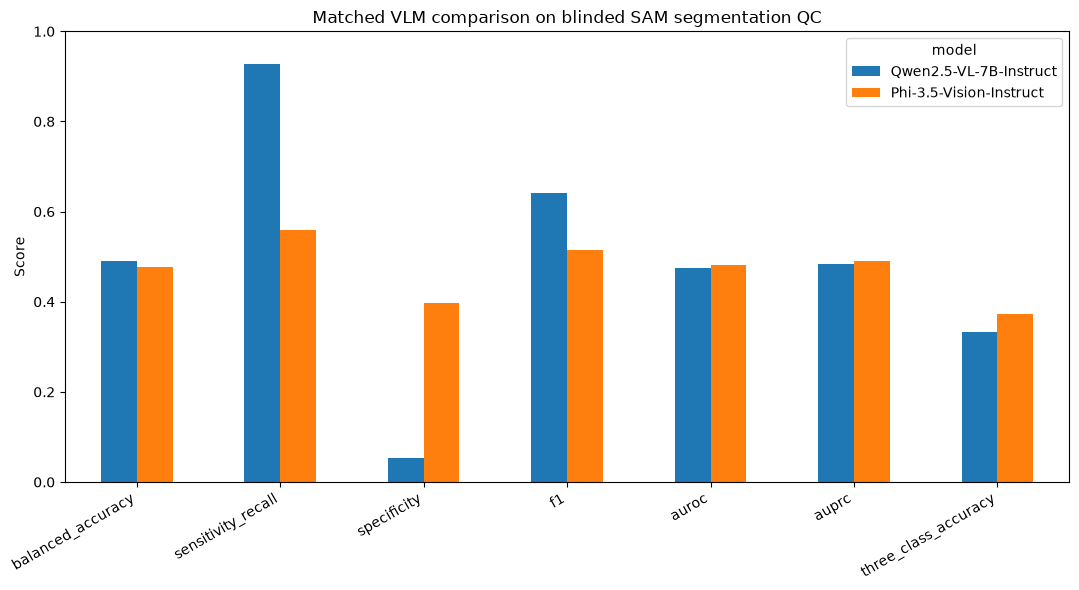

Saved: /content/drive/MyDrive/MedReasoner_SAM_2026/06_figures/03_qwen_vs_phi_matched_metric_comparison.png


In [21]:
# CELL 21 — Comparison figure
plot_cols=["balanced_accuracy","sensitivity_recall","specificity","f1","auroc","auprc","three_class_accuracy"]
ax=comparison[["model"]+plot_cols].set_index("model").T.plot(kind="bar",figsize=(11,6))
ax.set_ylim(0,1); ax.set_ylabel("Score"); ax.set_xlabel("")
ax.set_title("Matched VLM comparison on blinded SAM segmentation QC")
plt.xticks(rotation=30,ha="right"); plt.tight_layout()
FIG=FIG_DIR/"03_qwen_vs_phi_matched_metric_comparison.png"
plt.savefig(FIG,dpi=220,bbox_inches="tight"); plt.show()
print("Saved:",FIG)

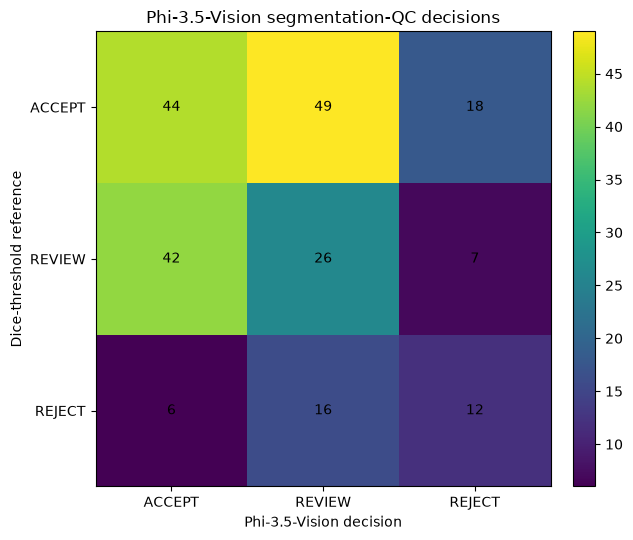

In [22]:
# CELL 22 — Phi confusion matrix
classes=["ACCEPT","REVIEW","REJECT"]
cm=confusion_matrix(valid["true_decision"],valid["decision"],labels=classes)
fig,ax=plt.subplots(figsize=(6.5,5.5)); im=ax.imshow(cm)
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(classes); ax.set_yticklabels(classes)
ax.set_xlabel("Phi-3.5-Vision decision"); ax.set_ylabel("Dice-threshold reference")
ax.set_title("Phi-3.5-Vision segmentation-QC decisions")
for i in range(3):
    for j in range(3): ax.text(j,i,str(cm[i,j]),ha="center",va="center")
fig.colorbar(im,ax=ax,fraction=0.046,pad=0.04); plt.tight_layout()
CM_FIG=FIG_DIR/f"{EXPERIMENT_ID}_confusion_matrix.png"
plt.savefig(CM_FIG,dpi=220,bbox_inches="tight"); plt.show()

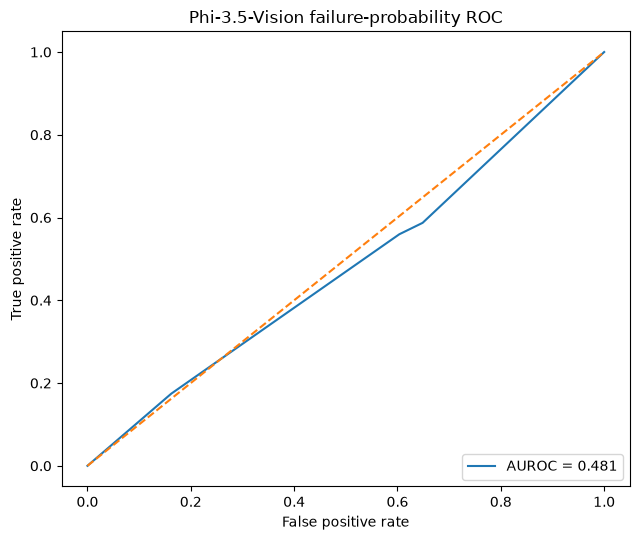

,n,spearman_rho_failure_probability_vs_1_minus_dice,p_value
0,220,0.046117,0.496197


In [23]:
# CELL 23 — Phi ROC + risk-quality association
y=valid["true_failure"].astype(int).to_numpy()
s=valid["failure_score"].to_numpy()
if len(np.unique(y))==2:
    fpr,tpr,_=roc_curve(y,s); auc=roc_auc_score(y,s)
    fig,ax=plt.subplots(figsize=(6.5,5.5))
    ax.plot(fpr,tpr,label=f"AUROC = {auc:.3f}"); ax.plot([0,1],[0,1],linestyle="--")
    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
    ax.set_title("Phi-3.5-Vision failure-probability ROC"); ax.legend(loc="lower right")
    plt.tight_layout()
    ROC_FIG=FIG_DIR/f"{EXPERIMENT_ID}_roc.png"
    plt.savefig(ROC_FIG,dpi=220,bbox_inches="tight"); plt.show()

rho,rho_p=spearmanr(valid["failure_score"],1.0-valid["stored_dice"],nan_policy="omit")
display(pd.DataFrame([{"n":len(valid),"spearman_rho_failure_probability_vs_1_minus_dice":rho,"p_value":rho_p}]))

In [24]:
# CELL 24 — Final results summary
summary={
    "experiment_id":EXPERIMENT_ID,
    "model":MODEL_ID,
    "model_commit":getattr(model.config,"_commit_hash",None),
    "prompt_version":PROMPT_VERSION,
    "num_crops":NUM_CROPS,
    "benchmark_cases":int(len(inf)),
    "unique_predictions":int(len(pred)),
    "parse_success_rate":float(pred["parse_ok"].mean()),
    "mean_generation_seconds":float(pred["generation_seconds"].mean()),
    "phi_primary_binary_metrics":phi_bin,
    "phi_three_class_metrics":phi_multi,
    "phi_risk_quality_association":{"spearman_rho":float(rho),"p_value":float(rho_p)},
    "paired_model_comparison":{
        "paired_n":int(len(paired)),
        "exact_three_class_agreement":agree3,
        "binary_failure_agreement":agree2,
        "exact_mcnemar_p":mcnemar_p
    }
}
SUMMARY_PATH=EVAL_DIR/f"{EXPERIMENT_ID}_summary.json"
SUMMARY_PATH.write_text(json.dumps(summary,indent=2))

print("="*88)
print("INDEPENDENT VLM REPLICATION RESULTS")
print("="*88)
print(f"Evaluable cases: {len(valid)} / {len(inf)}")
print(f"Parse success: {pred['parse_ok'].mean()*100:.1f}%")
print()
print("Phi-3.5-Vision primary binary endpoint")
print(f"  Balanced accuracy : {phi_bin['balanced_accuracy']:.3f}")
print(f"  Sensitivity       : {phi_bin['sensitivity_recall']:.3f}")
print(f"  Specificity       : {phi_bin['specificity']:.3f}")
print(f"  F1                : {phi_bin['f1']:.3f}")
print(f"  False reassurance : {phi_bin['false_reassurance_rate']:.3f}")
print(f"  AUROC             : {phi_bin['auroc']:.3f}")
print(f"  AUPRC             : {phi_bin['auprc']:.3f}")
print()
print("Phi three-class endpoint")
print(f"  Accuracy          : {phi_multi['accuracy']:.3f}")
print(f"  Macro F1          : {phi_multi['macro_f1']:.3f}")
print()
print("Matched Qwen vs Phi")
display(comparison)
print("Paired bootstrap differences (Phi minus Qwen)")
display(paired_diff)
print("Exact McNemar")
display(mcnemar)
print("Per-domain Phi results")
display(domain_metrics)
print("Summary saved:",SUMMARY_PATH)

INDEPENDENT VLM REPLICATION RESULTS
Evaluable cases: 220 / 220
Parse success: 100.0%

Phi-3.5-Vision primary binary endpoint
  Balanced accuracy : 0.478
  Sensitivity       : 0.560
  Specificity       : 0.396
  F1                : 0.515
  False reassurance : 0.440
  AUROC             : 0.481
  AUPRC             : 0.491

Phi three-class endpoint
  Accuracy          : 0.373
  Macro F1          : 0.362

Matched Qwen vs Phi


,model,balanced_accuracy,sensitivity_recall,specificity,f1,false_reassurance_rate,auroc,auprc,brier,three_class_accuracy,three_class_macro_f1
0,Qwen2.5-VL-7B-Instruct,0.490330,0.926606,0.054054,0.641270,0.073394,0.475122,0.483966,0.344909,0.331818,0.190956
1,Phi-3.5-Vision-Instruct,0.478015,0.559633,0.396396,0.514768,0.440367,0.480784,0.490639,0.427091,0.372727,0.361593


Paired bootstrap differences (Phi minus Qwen)


,metric,difference_phi_minus_qwen,ci95_low,ci95_high,bootstrap_probability_phi_gt_qwen
0,balanced_accuracy,-0.011954,-0.074466,0.051985,0.3478
1,auroc,0.006578,-0.066497,0.081268,0.5708


Exact McNemar


,paired_n,qwen_correct_phi_wrong,qwen_wrong_phi_correct,exact_mcnemar_p
0,220,40,38,0.909946


Per-domain Phi results


,n,balanced_accuracy,sensitivity_recall,specificity,precision,f1,false_reassurance_rate,false_alarm_rate,tp,tn,fp,fn,auroc,auprc,brier,domain,three_class_accuracy,three_class_macro_f1
0,94,0.518636,0.977273,0.06,0.477778,0.641791,0.022727,0.94,43,3,47,1,0.596818,0.541446,0.328032,brain_mri,0.340426,0.333900
1,36,0.500000,0.000000,1.00,0.000000,0.000000,1.000000,0.00,0,11,0,25,0.500000,0.694444,0.694444,histopathology,0.305556,0.156028
2,90,0.525000,0.450000,0.60,0.473684,0.461538,0.550000,0.40,18,30,20,22,0.502500,0.437259,0.423611,kidney_ct,0.433333,0.349451


Summary saved: /content/drive/MyDrive/MedReasoner_SAM_2026/05_evaluation/03_independent_vlm_replication_phi35vision_summary.json
